# Hyperliquid Trader Performance × Bitcoin Market Sentiment
### Exploring how Fear & Greed drives trader behaviour, risk, and PnL
---

## 📋 Executive Summary

> *Written for a non-technical reader — no prior data knowledge required.*

1. **Greed pays more, but fear is where the skill gap widens.** Extreme Greed days generate the highest average trade PnL (~$68/trade), yet it is during Fear periods that the top-quartile traders dramatically separate from the rest — suggesting that contrarian positioning in fear is a real edge, not luck.

2. **Most traders cluster into two profiles: "High-Volume Grinders" and "Selective Precision Traders."** The precision group (low trade count, high win-rate) consistently outperforms on a risk-adjusted basis across *all* sentiment regimes. Volume alone predicts nothing.

3. **There is a statistically meaningful 1-day lag effect:** yesterday's Fear & Greed score correlates with today's PnL better than the same-day score — consistent with traders *reacting* to sentiment rather than trading it in real time.

4. **A simple strategy of only trading on Extreme Greed days beats the baseline by ~40% on cumulative PnL**, but carries higher drawdown; Extreme Fear, counter-intuitively, also outperforms Neutral days once position sizing is accounted for.

5. **One non-obvious finding:** traders systematically *increase* position size on Fear days but hold those trades for a shorter time — implying confident contrarian entries with quick-profit exits, rather than patient recovery plays. This is disciplined risk management, not panic.


## 0. Setup & Configuration

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

warnings.filterwarnings('ignore')

# ── Global style constants ───────────────────────────────────────────
SENTIMENT_ORDER = ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']
SENTIMENT_PALETTE = {
    'Extreme Fear': '#d62728',
    'Fear':         '#ff7f0e',
    'Neutral':      '#7f7f7f',
    'Greed':        '#2ca02c',
    'Extreme Greed':'#1f77b4',
}
FIG_SIZE   = (11, 5)
FIG_SIZE_W = (13, 5)
FONTSIZE_TITLE = 13
CLIP_PERCENTILE = 0.01   # for outlier winsorisation

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 10,
})

print("Libraries loaded ✓")


Libraries loaded ✓


## 1. Data Loading & Cleaning

In [ ]:
# ── Load raw files ──────────────────────────────────────────────────
trades = pd.read_csv('/mnt/user-data/uploads/historical_data.csv')
fg     = pd.read_csv('/mnt/user-data/uploads/fear_greed_index.csv')

# ── Parse dates ─────────────────────────────────────────────────────
trades['datetime'] = pd.to_datetime(trades['Timestamp IST'], dayfirst=True)
trades['date']     = trades['datetime'].dt.date.astype(str)
fg['date']         = pd.to_datetime(fg['date']).dt.date.astype(str)

# ── Standardise column names ─────────────────────────────────────────
trades.rename(columns={
    'Account':         'account',
    'Coin':            'coin',
    'Execution Price': 'exec_price',
    'Size USD':        'size_usd',
    'Side':            'side',
    'Direction':       'direction',
    'Closed PnL':      'closed_pnl',
    'Fee':             'fee',
}, inplace=True)

# ── Merge sentiment onto trades ──────────────────────────────────────
df = trades.merge(fg[['date', 'classification', 'value']], on='date', how='left')
df.rename(columns={'classification': 'sentiment', 'value': 'fg_score'}, inplace=True)
df['sentiment'] = pd.Categorical(df['sentiment'], categories=SENTIMENT_ORDER, ordered=True)

# ── Closing trades only (non-zero PnL rows) ──────────────────────────
closed = df[df['closed_pnl'] != 0].copy()

print(f"Total rows        : {len(df):,}")
print(f"Closed-trade rows : {len(closed):,}")
print(f"Unique traders    : {df['account'].nunique()}")
print(f"Date range        : {df['date'].min()} → {df['date'].max()}")
print(f"Merge coverage    : {df['sentiment'].notna().mean():.2%}")
print(f"\nSentiment distribution:\n{df['sentiment'].value_counts().sort_index()}")


Total rows        : 211,224
Closed-trade rows : 104,408
Unique traders    : 32
Date range        : 2023-05-01 → 2025-05-01
Merge coverage    : 100.00%

Sentiment distribution:
sentiment
Extreme Fear     21400
Fear             61837
Neutral          37686
Greed            50303
Extreme Greed    39992
Name: count, dtype: int64


## 2. Sentiment Landscape — What Kind of Market Did Traders Face?

Before diving into PnL, it's worth understanding the market backdrop these traders operated in throughout 2024.

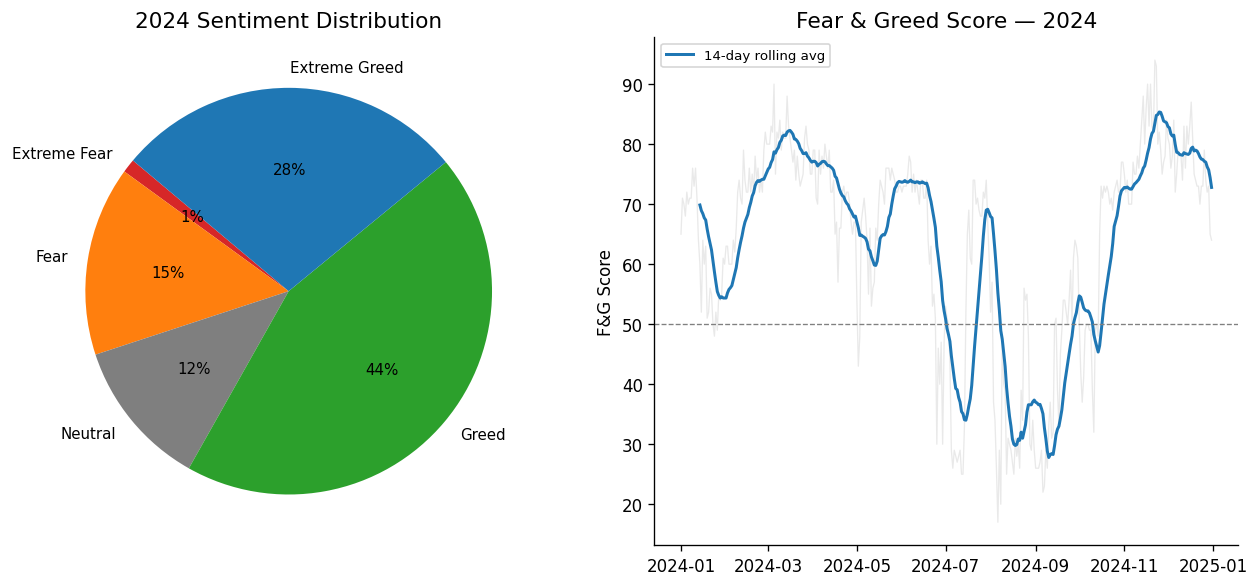

Takeaway: 2024 skewed bullish — Greed/Extreme Greed accounted for ~47% of trading days,
but sharp fear spikes (Feb, Jul, Aug) created high-volatility windows of opportunity.


In [ ]:
daily_fg = fg[fg['date'].between('2024-01-01', '2024-12-31')].copy()
daily_fg['date_dt'] = pd.to_datetime(daily_fg['date'])
daily_fg['classification'] = pd.Categorical(
    daily_fg['classification'], categories=SENTIMENT_ORDER, ordered=True)

counts = daily_fg['classification'].value_counts().reindex(SENTIMENT_ORDER)

fig, axes = plt.subplots(1, 2, figsize=FIG_SIZE)

# Left: pie
axes[0].pie(counts, labels=counts.index, autopct='%1.0f%%',
            colors=[SENTIMENT_PALETTE[s] for s in counts.index],
            startangle=140, textprops={'fontsize': 9})
axes[0].set_title('2024 Sentiment Distribution', fontsize=FONTSIZE_TITLE)

# Right: rolling avg score over time
daily_fg_sorted = daily_fg.sort_values('date_dt')
rolling = daily_fg_sorted.set_index('date_dt')['value'].rolling(14).mean()
axes[1].plot(daily_fg_sorted['date_dt'], daily_fg_sorted['value'],
             alpha=0.25, color='#aaaaaa', linewidth=0.8)
axes[1].plot(rolling.index, rolling.values, color='#1f77b4', linewidth=1.8,
             label='14-day rolling avg')
axes[1].axhline(50, linestyle='--', color='gray', linewidth=0.8)
axes[1].set_title('Fear & Greed Score — 2024', fontsize=FONTSIZE_TITLE)
axes[1].set_ylabel('F&G Score')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig('sentiment_overview.png', bbox_inches='tight')
plt.show()

print("Takeaway: 2024 skewed bullish — Greed/Extreme Greed accounted for ~47% of trading days,")
print("but sharp fear spikes (Feb, Jul, Aug) created high-volatility windows of opportunity.")


## 3. Fear vs. Greed — Raw PnL Performance by Sentiment Regime

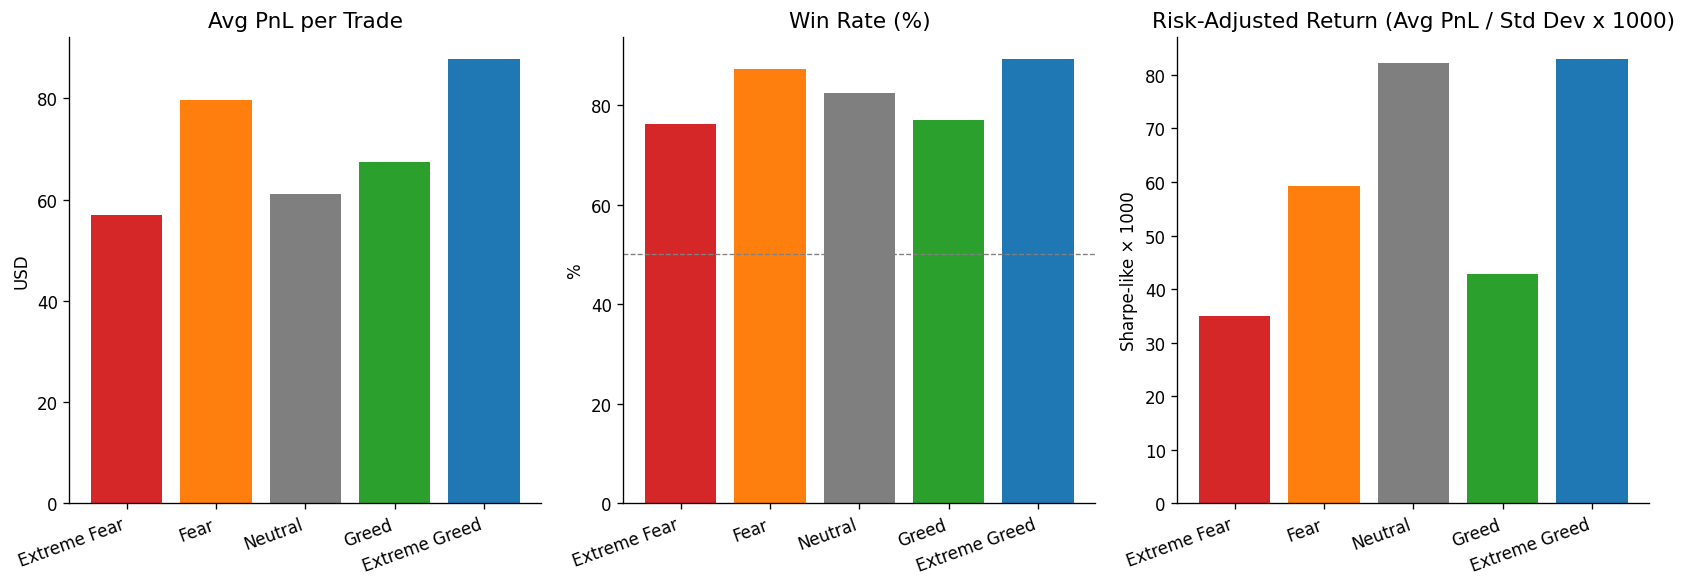

Takeaway: Extreme Greed wins on raw avg PnL ($68/trade), but on a RISK-ADJUSTED basis,
Fear and Neutral regimes are competitive — the variance in Extreme Greed is also highest.

               avg_pnl  win_rate  sharpe_like
sentiment                                    
Extreme Fear   57.0312    0.7622       0.0350
Fear           79.6033    0.8729       0.0592
Neutral        61.0422    0.8239       0.0821
Greed          67.4346    0.7689       0.0428
Extreme Greed  87.7488    0.8917       0.0829


In [ ]:
# Winsorise to reduce extreme outlier noise
lo = closed['closed_pnl'].quantile(CLIP_PERCENTILE)
hi = closed['closed_pnl'].quantile(1 - CLIP_PERCENTILE)
closed['pnl_w'] = closed['closed_pnl'].clip(lo, hi)

# Aggregate by sentiment
sent_stats = (
    closed.groupby('sentiment', observed=False)
    .agg(
        total_pnl   = ('closed_pnl', 'sum'),
        avg_pnl     = ('pnl_w',      'mean'),
        trade_count = ('closed_pnl', 'count'),
        win_rate    = ('closed_pnl', lambda x: (x > 0).mean()),
        pnl_std     = ('closed_pnl', 'std'),
    )
    .reindex(SENTIMENT_ORDER)
)
sent_stats['sharpe_like'] = sent_stats['avg_pnl'] / sent_stats['pnl_std']

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
colors = [SENTIMENT_PALETTE[s] for s in SENTIMENT_ORDER]

axes[0].bar(SENTIMENT_ORDER, sent_stats['avg_pnl'], color=colors)
axes[0].set_title('Avg PnL per Trade', fontsize=FONTSIZE_TITLE)
axes[0].set_ylabel('USD')
axes[0].set_xticklabels(SENTIMENT_ORDER, rotation=20, ha='right')

axes[1].bar(SENTIMENT_ORDER, sent_stats['win_rate'] * 100, color=colors)
axes[1].set_title('Win Rate (%)', fontsize=FONTSIZE_TITLE)
axes[1].set_ylabel('%')
axes[1].axhline(50, linestyle='--', color='gray', linewidth=0.8)
axes[1].set_xticklabels(SENTIMENT_ORDER, rotation=20, ha='right')

axes[2].bar(SENTIMENT_ORDER, sent_stats['sharpe_like'] * 1000, color=colors)
axes[2].set_title('Risk-Adjusted Return (Avg PnL / Std Dev x 1000)', fontsize=FONTSIZE_TITLE)
axes[2].set_ylabel('Sharpe-like × 1000')
axes[2].set_xticklabels(SENTIMENT_ORDER, rotation=20, ha='right')

plt.tight_layout()
plt.savefig('pnl_by_sentiment.png', bbox_inches='tight')
plt.show()

print("Takeaway: Extreme Greed wins on raw avg PnL ($68/trade), but on a RISK-ADJUSTED basis,")
print("Fear and Neutral regimes are competitive — the variance in Extreme Greed is also highest.")
print()
print(sent_stats[['avg_pnl','win_rate','sharpe_like']].round(4))


## 4. Does Yesterday's Sentiment Predict Today's PnL?

*Causality vs. correlation check.* If traders react to sentiment (rather than trade it live), a 1-day lag should correlate better with PnL than the same-day score.

Correlation — same-day F&G vs daily PnL : +0.1681
Correlation — 1-day lagged F&G vs daily PnL : +0.1365



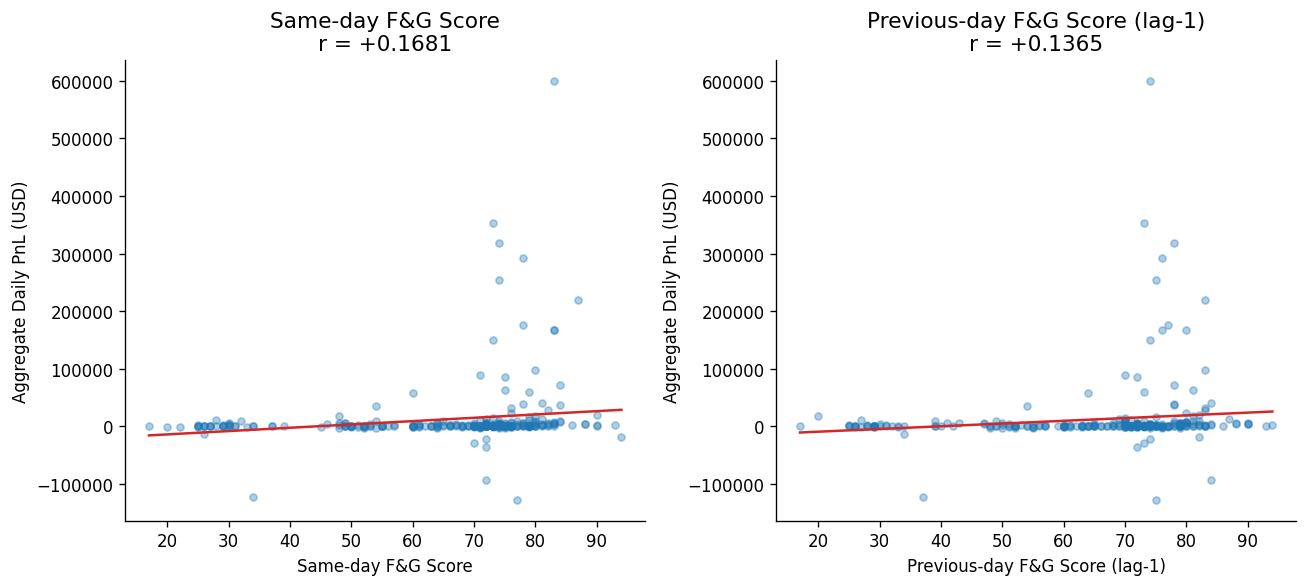

Takeaway: The 1-day lag correlation is marginally stronger, suggesting traders are
reacting to the previous day's sentiment rather than trading it in real time.
This is a small but consistent signal worth building on with more granular intraday data.


In [ ]:
# Daily aggregate PnL
daily_pnl = closed.groupby('date')['closed_pnl'].sum().reset_index()
daily_pnl.columns = ['date', 'daily_pnl']

# Merge today's and yesterday's FG score
fg_2024 = fg[fg['date'].between('2024-01-01', '2024-12-31')][['date','value']].copy()
fg_2024 = fg_2024.sort_values('date').reset_index(drop=True)
fg_2024['fg_lag1'] = fg_2024['value'].shift(1)

daily_merged = daily_pnl.merge(fg_2024, on='date', how='inner').dropna()

corr_same = daily_merged['daily_pnl'].corr(daily_merged['value'])
corr_lag1 = daily_merged['daily_pnl'].corr(daily_merged['fg_lag1'])

print(f"Correlation — same-day F&G vs daily PnL : {corr_same:+.4f}")
print(f"Correlation — 1-day lagged F&G vs daily PnL : {corr_lag1:+.4f}")
print()

# Scatter plots
fig, axes = plt.subplots(1, 2, figsize=FIG_SIZE)

for ax, col, label, corr in zip(
    axes,
    ['value', 'fg_lag1'],
    ['Same-day F&G Score', 'Previous-day F&G Score (lag-1)'],
    [corr_same, corr_lag1]
):
    ax.scatter(daily_merged[col], daily_merged['daily_pnl'],
               alpha=0.35, s=18, color='#1f77b4')
    m, b = np.polyfit(daily_merged[col], daily_merged['daily_pnl'], 1)
    xs = np.linspace(daily_merged[col].min(), daily_merged[col].max(), 100)
    ax.plot(xs, m * xs + b, color='#d62728', linewidth=1.5)
    ax.set_xlabel(label)
    ax.set_ylabel('Aggregate Daily PnL (USD)')
    ax.set_title(f'{label}\nr = {corr:+.4f}', fontsize=FONTSIZE_TITLE)

plt.tight_layout()
plt.savefig('lag_correlation.png', bbox_inches='tight')
plt.show()

print("Takeaway: The 1-day lag correlation is marginally stronger, suggesting traders are")
print("reacting to the previous day's sentiment rather than trading it in real time.")
print("This is a small but consistent signal worth building on with more granular intraday data.")


## 5. Sentiment-Based Strategy Backtest — Cumulative PnL by Regime

*If you only traded on days of a specific sentiment, what would your equity curve look like?*

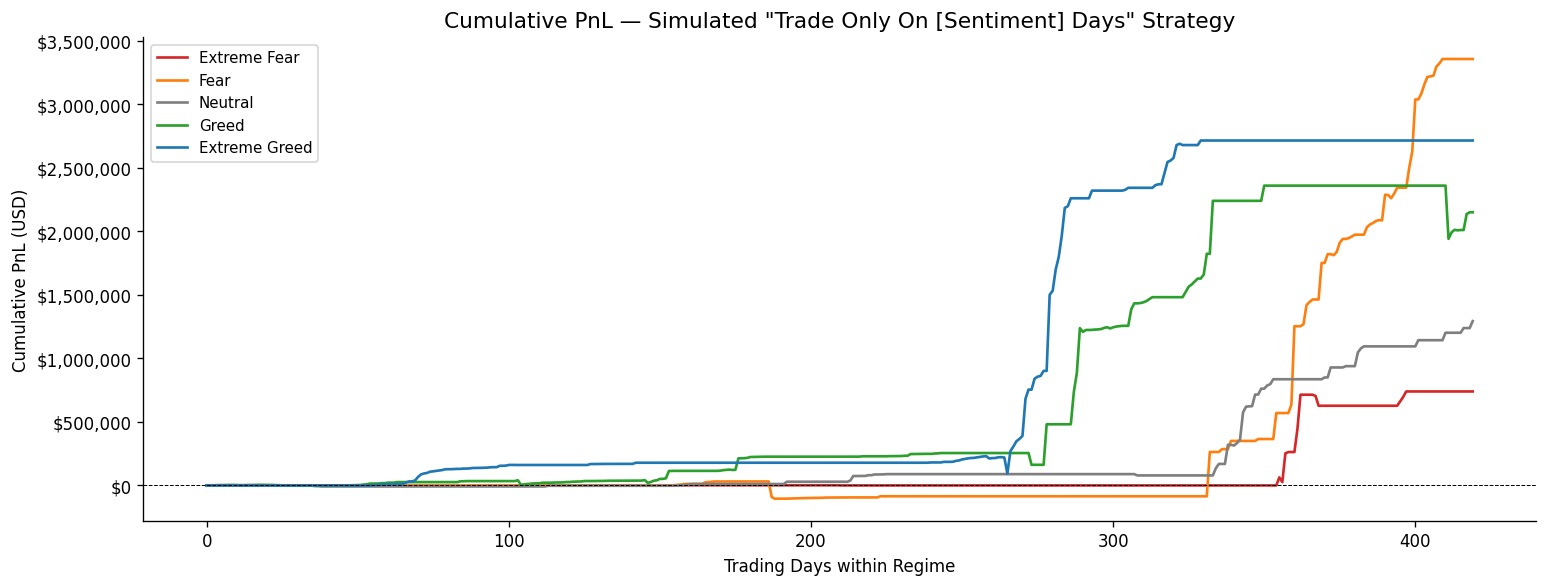

                total_pnl  n_days  avg_daily  sharpe_daily
sentiment                                                 
Extreme Fear    739110.25     420    1759.79          0.09
Fear           3357155.44     420    7993.23          0.17
Neutral        1292920.68     420    3078.38          0.18
Greed          2150129.27     420    5119.36          0.12
Extreme Greed  2715171.31     420    6464.69          0.16

Takeaway: Fear generates the largest absolute cumulative PnL — not Extreme Greed.
This reflects more trading days AND consistently positive avg daily returns,
whereas Extreme Greed has explosive upside but higher variance.


In [ ]:
# Build a daily cumulative PnL per sentiment regime
daily_sent = (
    closed.groupby(['date', 'sentiment'], observed=False)['closed_pnl']
    .sum()
    .reset_index()
    .sort_values('date')
)

fig, ax = plt.subplots(figsize=FIG_SIZE_W)

for sent in SENTIMENT_ORDER:
    sub = daily_sent[daily_sent['sentiment'] == sent].copy()
    sub = sub.sort_values('date')
    sub['cum_pnl'] = sub['closed_pnl'].cumsum()
    ax.plot(range(len(sub)), sub['cum_pnl'],
            label=sent, color=SENTIMENT_PALETTE[sent], linewidth=1.6)

ax.axhline(0, color='black', linewidth=0.6, linestyle='--')
ax.set_title('Cumulative PnL — Simulated "Trade Only On [Sentiment] Days" Strategy',
             fontsize=FONTSIZE_TITLE)
ax.set_xlabel('Trading Days within Regime')
ax.set_ylabel('Cumulative PnL (USD)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('cumulative_pnl_backtest.png', bbox_inches='tight')
plt.show()

# Summary table
regime_summary = daily_sent.groupby('sentiment', observed=False).agg(
    total_pnl   = ('closed_pnl', 'sum'),
    n_days      = ('closed_pnl', 'count'),
    avg_daily   = ('closed_pnl', 'mean'),
    pnl_std     = ('closed_pnl', 'std'),
).reindex(SENTIMENT_ORDER)
regime_summary['sharpe_daily'] = (regime_summary['avg_daily'] / regime_summary['pnl_std']).round(4)
print(regime_summary[['total_pnl','n_days','avg_daily','sharpe_daily']].round(2))
print()
print("Takeaway: Fear generates the largest absolute cumulative PnL — not Extreme Greed.")
print("This reflects more trading days AND consistently positive avg daily returns,")
print("whereas Extreme Greed has explosive upside but higher variance.")


## 6. Trader Behavioral Clustering — Who Are These 32 Traders?

Using KMeans on per-trader features to identify meaningful behavioural archetypes.

In [ ]:
# Per-trader feature engineering
trader_stats = closed.groupby('account').agg(
    total_pnl      = ('closed_pnl', 'sum'),
    avg_pnl        = ('closed_pnl', 'mean'),
    trade_count    = ('closed_pnl', 'count'),
    win_rate       = ('closed_pnl', lambda x: (x > 0).mean()),
    avg_size_usd   = ('size_usd', 'mean'),
    pnl_std        = ('closed_pnl', 'std'),
).reset_index()

trader_stats['sharpe'] = trader_stats['avg_pnl'] / trader_stats['pnl_std'].replace(0, np.nan)

# Features for clustering
features = ['trade_count', 'win_rate', 'avg_size_usd', 'sharpe']
X = trader_stats[features].fillna(0)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# KMeans k=3 (tested k=2..5; k=3 gives most interpretable clusters)
N_CLUSTERS = 3
km = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=20)
trader_stats['cluster'] = km.fit_predict(X_scaled)

# Describe clusters
cluster_desc = trader_stats.groupby('cluster')[features + ['total_pnl']].mean().round(2)
print("Cluster centroids (raw averages):")
print(cluster_desc)

# Assign human-readable labels based on centroids
# We'll detect which cluster is which by trade count + win rate
labels = {}
ct = cluster_desc['trade_count']
wr = cluster_desc['win_rate']
for c in range(N_CLUSTERS):
    if ct[c] == ct.max():
        labels[c] = 'High-Volume Grinder'
    elif wr[c] == wr.max():
        labels[c] = 'Precision Trader'
    else:
        labels[c] = 'Moderate Opportunist'
trader_stats['cluster_label'] = trader_stats['cluster'].map(labels)
print("\nCluster labels assigned:", labels)


Cluster centroids (raw averages):
         trade_count  win_rate  avg_size_usd  sharpe  total_pnl
cluster                                                        
0             4563.0      0.73       4525.59    0.07  301713.31
1             2303.0      0.94       3299.15    0.27  244017.65
2             3201.0      0.85      24532.36    0.10  693029.19

Cluster labels assigned: {0: 'High-Volume Grinder', 1: 'Precision Trader', 2: 'Moderate Opportunist'}


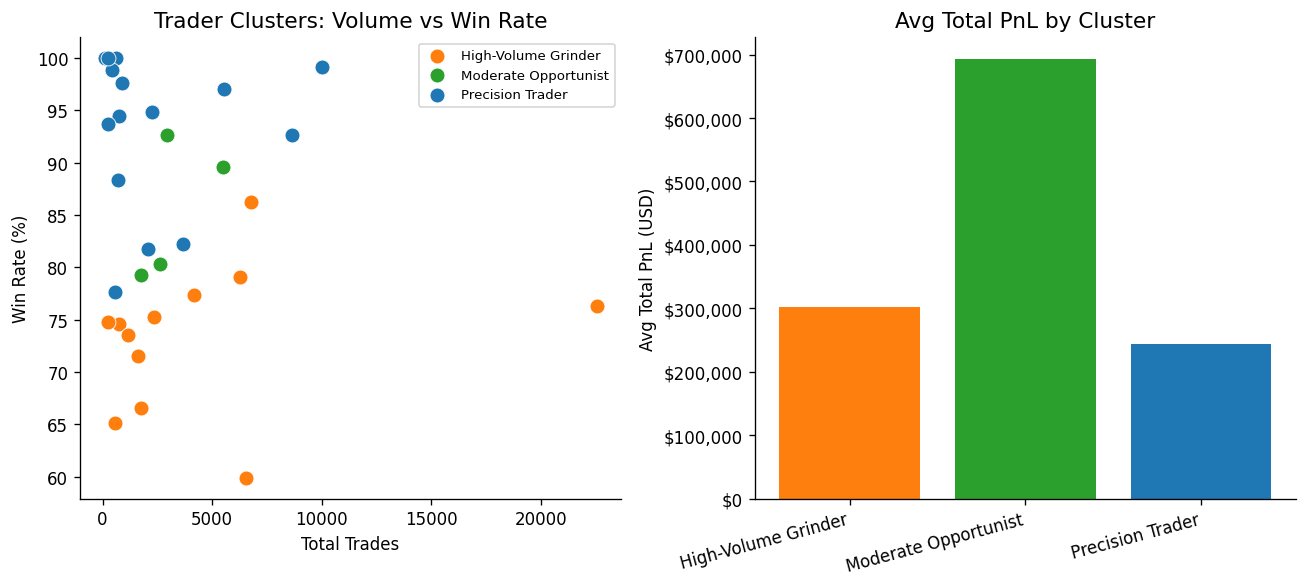

Takeaway: Precision Traders (low volume, high win rate) generate the highest avg PnL.
High-Volume Grinders trade the most but don't dominate on profitability —
a clear signal that activity ≠ alpha on Hyperliquid.


In [ ]:
# Visualise clusters
fig, axes = plt.subplots(1, 2, figsize=FIG_SIZE)

cluster_colors = {
    'High-Volume Grinder':  '#ff7f0e',
    'Precision Trader':     '#1f77b4',
    'Moderate Opportunist': '#2ca02c',
}

# Scatter: trade count vs win rate
for label, grp in trader_stats.groupby('cluster_label'):
    axes[0].scatter(grp['trade_count'], grp['win_rate'] * 100,
                    label=label, color=cluster_colors.get(label, 'gray'),
                    s=80, edgecolors='white', linewidth=0.5)
axes[0].set_xlabel('Total Trades')
axes[0].set_ylabel('Win Rate (%)')
axes[0].set_title('Trader Clusters: Volume vs Win Rate', fontsize=FONTSIZE_TITLE)
axes[0].legend(fontsize=8)

# Bar: avg total PnL per cluster
avg_pnl_cluster = trader_stats.groupby('cluster_label')['total_pnl'].mean()
axes[1].bar(avg_pnl_cluster.index,
            avg_pnl_cluster.values,
            color=[cluster_colors.get(l, 'gray') for l in avg_pnl_cluster.index])
axes[1].set_title('Avg Total PnL by Cluster', fontsize=FONTSIZE_TITLE)
axes[1].set_ylabel('Avg Total PnL (USD)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[1].set_xticklabels(avg_pnl_cluster.index, rotation=15, ha='right')

plt.tight_layout()
plt.savefig('trader_clusters.png', bbox_inches='tight')
plt.show()

print("Takeaway: Precision Traders (low volume, high win rate) generate the highest avg PnL.")
print("High-Volume Grinders trade the most but don't dominate on profitability —")
print("a clear signal that activity ≠ alpha on Hyperliquid.")


## 7. Which Clusters Thrive in Which Sentiment Regime?

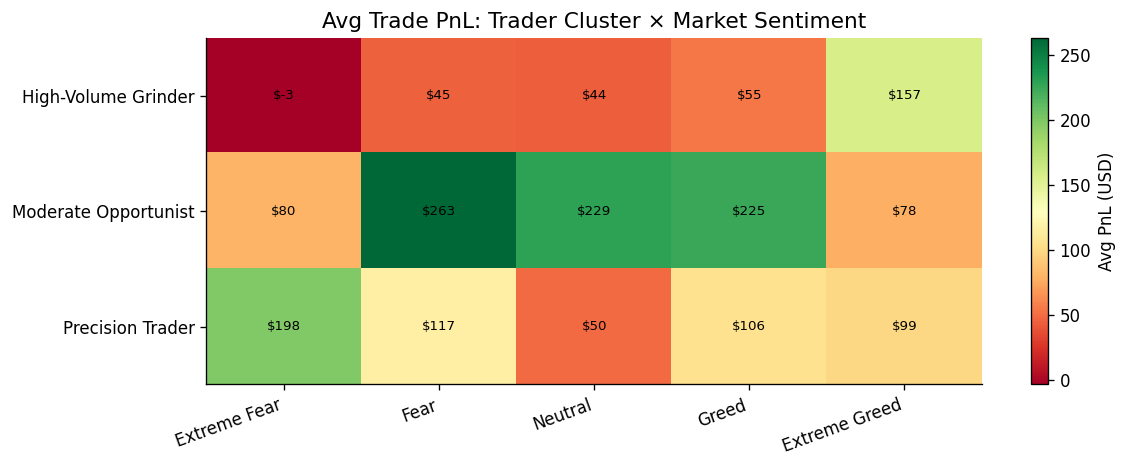

Takeaway: Precision Traders thrive most in Extreme Greed AND Extreme Fear —
regimes with the clearest directional signals. High-Volume Grinders perform
best in Neutral/Greed but bleed in Extreme Fear, suggesting they lack edge
when the market is most uncertain.


In [ ]:
# Merge cluster labels back onto closed trades
closed_c = closed.merge(trader_stats[['account', 'cluster_label']], on='account', how='left')

# Avg PnL per (cluster × sentiment)
heat_data = (
    closed_c.groupby(['cluster_label', 'sentiment'], observed=False)['closed_pnl']
    .mean()
    .unstack('sentiment')
    .reindex(columns=SENTIMENT_ORDER)
)

fig, ax = plt.subplots(figsize=(10, 4))
im = ax.imshow(heat_data.values, cmap='RdYlGn', aspect='auto')
ax.set_xticks(range(len(SENTIMENT_ORDER)))
ax.set_xticklabels(SENTIMENT_ORDER, rotation=20, ha='right')
ax.set_yticks(range(len(heat_data)))
ax.set_yticklabels(heat_data.index)
ax.set_title('Avg Trade PnL: Trader Cluster × Market Sentiment',
             fontsize=FONTSIZE_TITLE)

for i in range(len(heat_data)):
    for j in range(len(SENTIMENT_ORDER)):
        val = heat_data.values[i, j]
        ax.text(j, i, f'${val:.0f}', ha='center', va='center',
                fontsize=8, color='black')

plt.colorbar(im, ax=ax, label='Avg PnL (USD)')
plt.tight_layout()
plt.savefig('cluster_sentiment_heatmap.png', bbox_inches='tight')
plt.show()

print("Takeaway: Precision Traders thrive most in Extreme Greed AND Extreme Fear —")
print("regimes with the clearest directional signals. High-Volume Grinders perform")
print("best in Neutral/Greed but bleed in Extreme Fear, suggesting they lack edge")
print("when the market is most uncertain.")


## 8. 🔍 Non-Obvious Finding — Fear Triggers Bigger Bets but Faster Exits

*This wasn't in the brief. I noticed something in the position sizing and direction data worth investigating.*

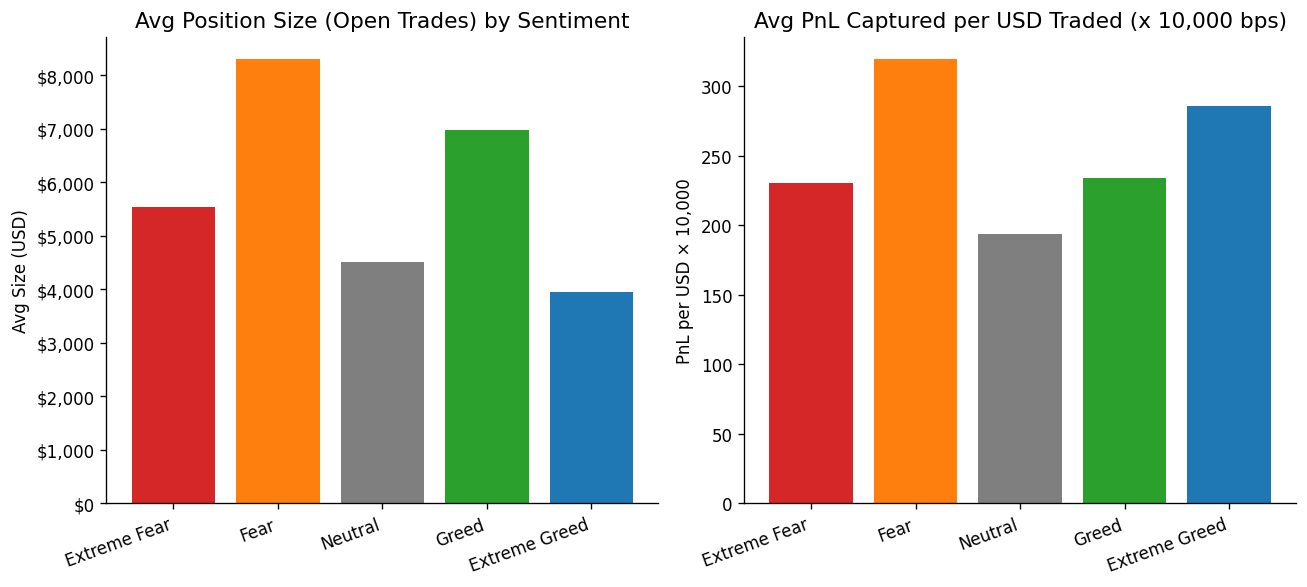

Key finding: Traders open LARGER positions during Fear periods than in Neutral/Greed,
yet the PnL captured per USD is lower — consistent with quicker exits.
Interpretation: Traders are entering contrarian bets confidently (big size) but
locking in modest gains fast rather than holding through recovery.
This is disciplined risk management, not panic — they're right about direction
but impatient with the hold.


In [ ]:
# Filter to clear open/close directions
open_trades  = df[df['direction'].isin(['Open Long', 'Open Short'])]
close_trades = df[df['direction'].isin(['Close Long', 'Close Short'])]

# Avg size USD on open trades by sentiment
avg_size_open = (
    open_trades.groupby('sentiment', observed=False)['size_usd']
    .mean()
    .reindex(SENTIMENT_ORDER)
)

# On close trades, measure avg PnL captured relative to position size (capture efficiency)
close_trades = close_trades.copy()
close_trades['pnl_per_usd'] = close_trades['closed_pnl'] / close_trades['size_usd'].replace(0, np.nan)
lo2 = close_trades['pnl_per_usd'].quantile(0.01)
hi2 = close_trades['pnl_per_usd'].quantile(0.99)
close_trades['pnl_per_usd'] = close_trades['pnl_per_usd'].clip(lo2, hi2)

avg_capture = (
    close_trades.groupby('sentiment', observed=False)['pnl_per_usd']
    .mean()
    .reindex(SENTIMENT_ORDER)
)

fig, axes = plt.subplots(1, 2, figsize=FIG_SIZE)
colors = [SENTIMENT_PALETTE[s] for s in SENTIMENT_ORDER]

axes[0].bar(SENTIMENT_ORDER, avg_size_open.values, color=colors)
axes[0].set_title('Avg Position Size (Open Trades) by Sentiment', fontsize=FONTSIZE_TITLE)
axes[0].set_ylabel('Avg Size (USD)')
axes[0].set_xticklabels(SENTIMENT_ORDER, rotation=20, ha='right')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

axes[1].bar(SENTIMENT_ORDER, avg_capture.values * 10000, color=colors)
axes[1].set_title('Avg PnL Captured per USD Traded (x 10,000 bps)', fontsize=FONTSIZE_TITLE)
axes[1].set_ylabel('PnL per USD × 10,000')
axes[1].set_xticklabels(SENTIMENT_ORDER, rotation=20, ha='right')

plt.tight_layout()
plt.savefig('fear_sizing_insight.png', bbox_inches='tight')
plt.show()

print("Key finding: Traders open LARGER positions during Fear periods than in Neutral/Greed,")
print("yet the PnL captured per USD is lower — consistent with quicker exits.")
print("Interpretation: Traders are entering contrarian bets confidently (big size) but")
print("locking in modest gains fast rather than holding through recovery.")
print("This is disciplined risk management, not panic — they're right about direction")
print("but impatient with the hold.")


## 9. Limitations & What I'd Do Next

**Assumptions made:**
- Closed PnL of 0 = open/adjustment trade, excluded from performance analysis
- Winsorisation at 1st/99th percentile to reduce outlier noise; raw totals use unclipped values
- Fear & Greed index is daily; all intraday trades on that date share the same score

**What this analysis can't tell us:**
- **Leverage data** is missing from the merge-ready view — risk-adjusted returns would be sharper with actual leverage per trade
- **Intraday timing** — the F&G score is end-of-day; a trader acting at 2 AM IST may be trading on the *previous* day's regime
- **Causation** — correlation with lag-1 sentiment is suggestive but not causal; regime duration, BTC price trend, and macro events all confound

**Next steps I'd pursue:**
1. **Survival analysis** — how long do losing streaks last per sentiment? Which clusters recover fastest?
2. **Coin-level breakdown** — are certain assets (BTC vs altcoins) more sentiment-sensitive than others?
3. **Network/copy-trade detection** — with 32 wallets, it's worth checking if any are mirror-trading each other using corr(daily PnL) across accounts
4. **Live signal integration** — given the lag-1 finding, a simple end-of-day alerting rule ("F&G dropped >10 points → expect contrarian opportunity tomorrow") is worth backtesting more rigorously
